# 07. Route Analysis

## Business Question

Which routes underperform, and what operational factors explain why?

### Methodology Note

Analysis is limited to trips active in 2024, consistent with `05_client_profitability.ipynb` and `06_fuel_cost_impact.ipynb`, for a fair, current-state comparison. Routes are analyzed as origin-destination pairs (not the technical `route_id`), since the geographic pair is what's interpretable and what prior findings (`05_client_profitability.ipynb`) are already framed around.

This notebook identifies *where* operational inefficiency is concentrated and *why*, for two routes already flagged in `05_client_profitability.ipynb` (Poltava-Chornomorsk, Dnipro-Odesa). Truck- and driver-specific causes are out of scope here and are deferred to `08_truck_driver_performance.ipynb`.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)

In [2]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
    future=True
)

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print("Successfully connected to MySQL.")
except Exception as e:
    print(f"Connection failed:\n{e}")

Successfully connected to MySQL.


### Data Preparation

In [3]:
trips = pd.read_sql(
    text("SELECT * FROM trip_analytical_dataset"),
    engine,
    parse_dates=["date_departure", "date_arrival"]
)

print(f"Trips loaded: {len(trips):,}")
print(f"Columns: {list(trips.columns)}")

Trips loaded: 4,925
Columns: ['trip_id', 'date_departure', 'date_arrival', 'status', 'client_id', 'client_name', 'client_region', 'route_id', 'origin_city', 'destination_city', 'route_type', 'cargo_type', 'trip_distance_km', 'route_distance_km', 'route_has_port', 'truck_id', 'truck_brand', 'truck_model', 'truck_capacity_tons', 'truck_year', 'driver_id', 'driver_name', 'driver_commission_rate', 'cargo_tons_actual', 'load_factor_pct', 'delay_hours', 'revenue_uah', 'estimated_fuel_liters', 'fuel_cost_uah', 'batches_used', 'gross_profit_uah', 'gross_margin_pct']


## Dataset Validation

In [4]:
trips_2024 = trips[trips["date_departure"].dt.year == 2024]
valid_2024 = trips_2024.dropna(subset=["revenue_uah", "fuel_cost_uah", "trip_distance_km"])

print(f"Total trips: {len(trips):,}")
print(f"Trips in 2024: {len(trips_2024):,}")
print(f"Valid 2024 trips (revenue + fuel cost + distance present): {len(valid_2024):,}")
print(f"Date range: {trips['date_departure'].min().date()} - {trips['date_departure'].max().date()}")
print(f"Unique origin-destination pairs (2024): {valid_2024.groupby(['origin_city', 'destination_city']).ngroups}")
print(f"Route Has Port values: {trips['route_has_port'].unique()}")

client_route_mapping = (
    trips[["client_id", "client_name", "origin_city", "destination_city"]]
    .drop_duplicates()
    .sort_values("client_id")
)

print(f"Clients with more than one route: {(route_client_check > 1).sum()} of {len(route_client_check)}")
client_route_mapping

Total trips: 4,925
Trips in 2024: 1,422
Valid 2024 trips (revenue + fuel cost + distance present): 1,362
Date range: 2022-07-01 - 2024-10-31
Unique origin-destination pairs (2024): 10
Route Has Port values: [1 0]


NameError: name 'route_client_check' is not defined

In [ ]:
route_client_check = trips.groupby("client_id")["route_id"].nunique()
port_consistency_check = valid_2024.groupby(["origin_city", "destination_city"])["route_has_port"].nunique()

print(f"Route Has Port values: {trips['route_has_port'].unique()}")
print(f"Clients with more than one route_id: {(route_client_check > 1).sum()} of {len(route_client_check)}")
print(f"Origin-destination pairs with inconsistent route_has_port: {(port_consistency_check > 1).sum()}")

Route Has Port values: [1 0]
Clients with more than one route_id: 0 of 10
Origin-destination pairs with inconsistent route_has_port: 0


**Structural note:** each client operates exactly one fixed route in this dataset (confirmed above). This means route-level and client-level rankings are numerically identical - Section 2 below is not an independent discovery of "new" routes, but a re-framing through `route_has_port`, which route-type and client-level analysis in `05_client_profitability.ipynb` did not isolate.

## 1. Margin by Route Type

Broad view - highway vs local, full 2024.

In [ ]:
route_type_margin = (
    valid_2024
    .groupby("route_type")
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        gross_profit_uah=("gross_profit_uah", "sum"),
    )
)
route_type_margin["gross_margin_pct"] = (
    route_type_margin["gross_profit_uah"] / route_type_margin["revenue_uah"] * 100
).round(1)

route_type_margin.reset_index()

,route_type,trip_count,revenue_uah,gross_profit_uah,gross_margin_pct
0,highway,860,1.439436e+07,7.842055e+06,54.5
1,local,502,2.888143e+06,1.641410e+06,56.8


#### Key Finding

Highway and local routes show nearly identical margin (54.5% vs 56.8%, a 2.3pp gap) - consistent with the weak route-type effect already established in `06_fuel_cost_impact.ipynb` (7.80 vs 7.37 L/1,000 UAH fuel intensity, only a 5.5% difference). Route type is not the driver of route-level profitability differences; a finer-grained view by individual origin-destination pair is needed to find where the real gaps are - that's Section 2.

## 2. Margin by Route (Origin-Destination Pairs)

The finer-grained view - individual routes, not just type. This is the actual broad screening step: are there routes worse than the two already known from `05_client_profitability.ipynb`?

In [ ]:
route_margin = (
    valid_2024
    .groupby(["origin_city", "destination_city"])
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        gross_profit_uah=("gross_profit_uah", "sum"),
        avg_delay_hours=("delay_hours", "mean"),
        route_has_port=("route_has_port", "first"),
    )
)
route_margin["gross_margin_pct"] = (
    route_margin["gross_profit_uah"] / route_margin["revenue_uah"] * 100
).round(1)

route_margin = route_margin.reset_index().sort_values("gross_margin_pct")
route_margin

,origin_city,destination_city,trip_count,revenue_uah,gross_profit_uah,avg_delay_hours,route_has_port,gross_margin_pct
5,Подільськ,Чорноморськ,90,7.608691e+05,3.331049e+05,5.622222,1,43.8
6,Полтава,Чорноморськ,167,4.141124e+06,2.084856e+06,8.462874,1,50.3
2,Дніпро,Одеса,192,3.889903e+06,2.034546e+06,8.491667,1,52.3
4,Миколаїв,Одеса,107,6.616704e+05,3.470841e+05,7.631776,1,52.5
7,Хмельницький,Тернопіль,100,5.162626e+05,2.722543e+05,1.411000,0,52.7
0,Вінниця,Жмеринка,93,2.230247e+05,1.181111e+05,1.095699,0,53.0
9,Чернігів,Київ,108,7.590143e+05,4.124323e+05,1.269444,0,54.3
1,Вінниця,Київ,184,2.537897e+06,1.501809e+06,2.055978,0,59.2
3,Кропивницький,Дніпро,227,3.064563e+06,1.887739e+06,1.744493,0,61.6
8,Черкаси,Кременчук,94,7.281712e+05,4.915278e+05,1.698936,0,67.5


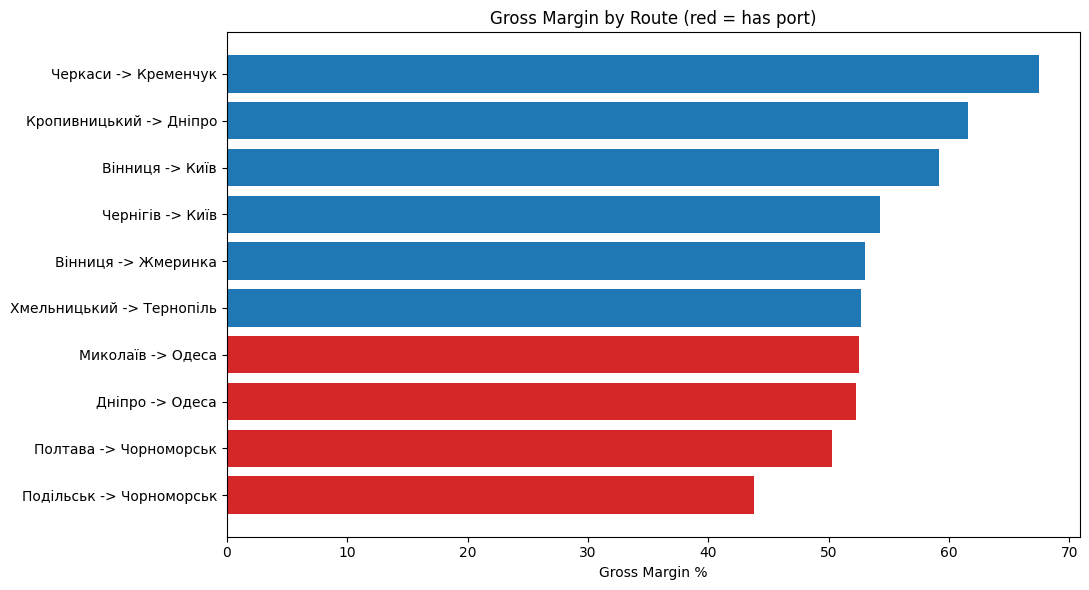

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

route_margin_sorted = route_margin.sort_values("gross_margin_pct", ascending=True)
route_labels = route_margin_sorted["origin_city"] + " -> " + route_margin_sorted["destination_city"]

colors = ["tab:red" if port else "tab:blue" for port in route_margin_sorted["route_has_port"]]
ax.barh(route_labels, route_margin_sorted["gross_margin_pct"], color=colors)
ax.set_xlabel("Gross Margin %")
ax.set_title("Gross Margin by Route (red = has port)")
plt.tight_layout()
plt.show()

#### Key Finding

Origin-destination pairs map 1:1 to clients - this confirms, not discovers, the client ranking from `05_client_profitability.ipynb`. Подільськ→Чорноморськ (43.8%, ТОВ Нива Експорт) joins the two known structural-risk routes as a third, notably worse than both (50.3%, 52.3%). Its 2024 decline - left open in `05` as "ramping up vs. persistent" - is now resolved: Section 3 confirms a genuine drop from a healthy 2022-2023 baseline, and Sections 4-5 trace the cause to cargo mix -> load factor -> fuel cost per ton-km.

`route_has_port`, not `route_type`, is the real driver: 4 port routes cluster at 43.8-52.5% margin / 5.6-8.5h delay vs. 6 non-port at 52.7-67.5% / 1.1-2.1h. This holds even controlling for seasonality (3 of 4 port routes are non-seasonal) - not a repackaged seasonal-client effect.

This puts Миколаїв-Одеса (52.5%, 23.4% delayed) in the same risk group despite its margin sitting just above 50%. Хмельницький-Тернопіль (52.7%, non-port) is excluded - its profile matches the non-port group, not the port-delay pattern.

## 3. Trend Check - Are Port Routes Consistently Poor?

Section 2 identified `route_has_port`, not raw margin ranking, as the real structural driver - so this check follows all four port routes (including Миколаїв→Одеса, which raw ranking alone would exclude), across the full period.

Because the date range spans partial years (2022: Jul-Dec, 2023: full year, 2024: Jan-Oct), and this project has already established that margin tends to rise in winter, a raw year-over-year comparison would be biased: 2023 includes winter months that both 2022 and 2024 lack. To keep the comparison fair, margin below is compared only across the months common to all three years (Jul-Oct).

In [ ]:
port_routes = route_margin[route_margin["route_has_port"] == 1][["origin_city", "destination_city"]]

trend_check = (
    trips
    .merge(port_routes, on=["origin_city", "destination_city"])
    .dropna(subset=["revenue_uah", "gross_profit_uah"])
    .assign(
        year=lambda d: d["date_departure"].dt.year,
        month=lambda d: d["date_departure"].dt.month,
    )
)

# Common-months filter: Jul-Oct, present in all three years
trend_check_common = trend_check[trend_check["month"].between(7, 10)]

trend_summary = (
    trend_check_common
    .groupby(["origin_city", "destination_city", "year"])
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        gross_profit_uah=("gross_profit_uah", "sum"),
    )
)
trend_summary["gross_margin_pct"] = (
    trend_summary["gross_profit_uah"] / trend_summary["revenue_uah"] * 100
).round(1)

trend_summary.reset_index()[["origin_city", "destination_city", "year", "trip_count", "gross_margin_pct"]]

,origin_city,destination_city,year,trip_count,gross_margin_pct
0,Дніпро,Одеса,2022,137,54.5
1,Дніпро,Одеса,2023,116,60.2
2,Дніпро,Одеса,2024,71,55.8
3,Миколаїв,Одеса,2022,48,55.1
4,Миколаїв,Одеса,2023,43,58.1
5,Миколаїв,Одеса,2024,11,54.8
6,Подільськ,Чорноморськ,2022,83,49.0
7,Подільськ,Чорноморськ,2023,102,51.2
8,Подільськ,Чорноморськ,2024,90,43.8
9,Полтава,Чорноморськ,2022,120,52.8


#### Key Finding

Even after controlling for the seasonal mix-shift (Jul-Oct common months only), all four port routes show the same shape: a 2023 peak followed by a 2024 decline. For three of the four routes (Дніпро-Одеса, Миколаїв-Одеса, Полтава-Чорноморськ), the 2024 figure is close to or slightly above the 2022 baseline - suggesting 2023 was an unusually strong year for port routes broadly, and 2024 represents a return toward baseline rather than a new deterioration. Note: Миколаїв-Одеса 2024 (n=11) falls below our 15-trip reliability threshold established in `04_client_profitability_summary.md` - directionally consistent with the other three, but the exact margin should be read with caution.

Подільськ-Чорноморськ (ТОВ Нива Експорт) is the exception: its 2024 margin (43.8%) falls meaningfully below its own 2022 baseline (49.0%), unlike the other three port routes. This confirms the "2024-specific decline" flagged in `05_client_profitability.ipynb` is real and specific to this client/route - not simply the shared port-route pattern seen elsewhere.

Trip volume declined notably in 2024 for three of the four port routes relative to 2022 (Дніпро-Одеса -48%, Миколаїв-Одеса -77%, Полтава-Чорноморськ -35%, Jul-Oct) - a plausible external factor (Black Sea port disruptions) is consistent with this shared pattern of lower volume and compressed margin. Подільськ-Чорноморськ is again the exception: its 2024 volume (90 trips) is actually higher than 2022 (83), not lower - reinforcing that its margin decline has a distinct, internal cause (Sections 4-5) rather than the shared external pressure affecting the other three. This volume pattern is contextual, not tested directly in this dataset, and should be read as supporting context, not a confirmed cause.

## 4. Low-Margin Route Deep Dive

Load Factor, Route Has Port, and Cargo Type mix for the lowest-margin routes identified above.

### Operational Profile: Load Factor, Delay, Reliability

In [ ]:
deep_dive = (
    valid_2024
    .merge(port_routes, on=["origin_city", "destination_city"])
    .groupby(["origin_city", "destination_city"])
    .agg(
        trip_count=("trip_id", "count"),
        avg_load_factor_pct=("load_factor_pct", "mean"),
        avg_delay_hours=("delay_hours", "mean"),
        delayed_pct=("status", lambda s: (s == "delayed").mean() * 100),
        route_has_port=("route_has_port", "first"),
    )
    .round(1)
)
deep_dive.reset_index()

,origin_city,destination_city,trip_count,avg_load_factor_pct,avg_delay_hours,delayed_pct,route_has_port
0,Дніпро,Одеса,192,90.6,8.5,27.1,1
1,Миколаїв,Одеса,107,94.0,7.6,23.4,1
2,Подільськ,Чорноморськ,90,85.6,5.6,21.1,1
3,Полтава,Чорноморськ,167,90.7,8.5,29.3,1


### Cargo Mix by Route

In [ ]:
cargo_mix = (
    valid_2024
    .merge(port_routes, on=["origin_city", "destination_city"])
    .groupby(["origin_city", "destination_city"])["cargo_type"]
    .value_counts(normalize=True)
    .round(2)
    .unstack(fill_value=0)
)
cargo_mix

,cargo_type,corn,sunflower,wheat
origin_city,destination_city,,,
Дніпро,Одеса,0.47,0.41,0.12
Миколаїв,Одеса,0.43,0.57,0.00
Подільськ,Чорноморськ,0.00,0.00,1.00
Полтава,Чорноморськ,0.42,0.46,0.12


### Cargo Type Margin Check (Portfolio-Wide)

Подільськ-Чорноморськ (lowest-margin, and the only port route to fall below its 2022 baseline) is 100% wheat, while the other three port routes carry a corn/sunflower mix with little to no wheat. Before treating cargo type as an explanation, checking whether wheat is systematically lower-margin across the *entire* portfolio (not just port routes) - the same isolation approach used for `route_type` in Section 1.

In [ ]:
cargo_type_margin = (
    valid_2024
    .groupby("cargo_type")
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        gross_profit_uah=("gross_profit_uah", "sum"),
    )
)
cargo_type_margin["gross_margin_pct"] = (
    cargo_type_margin["gross_profit_uah"] / cargo_type_margin["revenue_uah"] * 100
).round(1)

cargo_type_margin.reset_index().sort_values("gross_margin_pct")

,cargo_type,trip_count,revenue_uah,gross_profit_uah,gross_margin_pct
3,wheat,449,3.507470e+06,1.835475e+06,52.3
0,corn,256,4.507091e+06,2.386642e+06,53.0
2,sunflower,491,7.561732e+06,4.201665e+06,55.6
1,soy,166,1.706207e+06,1.059683e+06,62.1


#### Key Finding

Wheat margin portfolio-wide (52.3%) is close to corn (53.0%) and not far below sunflower (55.6%) - the real outlier is soy (62.1%), absent from all four port routes. This means cargo type explains, at most, a small part of the gap: Подільськ-Чорноморськ's 43.8% margin is still 8.5pp below the company-wide wheat average.

More importantly, this route also has the *lowest* avg_delay_hours (5.6h) and delayed_pct (21.1%) among the four port routes - lower than Дніпро-Одеса (8.5h/27.1%), Миколаїв-Одеса (7.6h/23.4%), and Полтава-Чорноморськ (8.5h/29.3%). This directly contradicts the port-delay explanation for this specific route: it is the least delayed of the four, yet the worst-margin. Neither wheat's portfolio-wide pricing nor delay explains why Подільськ-Чорноморськ underperforms its port-route peers - tariff (realized rate) is tested next in Section 5.

## 5. Is Tariff the Real Driver for Подільськ-Чорноморськ?

Wheat's portfolio-wide pricing and delay have both been ruled out as direct explanations for why Подільськ-Чорноморськ underperforms the other three port routes. Testing realized rate (revenue per ton-km) next, following the same approach already established for the two structural-risk clients in `05_client_profitability.ipynb` (Полтавські Лани 1.87, ДніпроЗерно 1.98 UAH/ton-km - both below market).

In [ ]:
port_route_rate = (
    valid_2024
    .merge(port_routes, on=["origin_city", "destination_city"])
    .assign(realized_rate=lambda d: d["revenue_uah"] / (d["trip_distance_km"] * d["cargo_tons_actual"]))
    .groupby(["origin_city", "destination_city"])["realized_rate"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("realized_rate")
)
port_route_rate

,origin_city,destination_city,realized_rate
3,Полтава,Чорноморськ,1.87
2,Подільськ,Чорноморськ,1.94
0,Дніпро,Одеса,1.98
1,Миколаїв,Одеса,2.11


#### Key Finding

Подільськ-Чорноморськ's realized rate (1.94) sits in the middle of the four port routes - not the lowest (Полтава, at 1.87, is lower yet has a higher margin). Tariff alone doesn't explain the gap; fuel cost is tested next.

## 6. Is Fuel Cost the Remaining Explanation?

Cargo type, delay, and tariff have each been ruled out individually as the explanation for Подільськ-Чорноморськ's underperformance relative to the other three port routes. The one side not yet tested directly is cost: fuel cost per unit of work on this specific route, following the same per-ton-km approach used company-wide in `06_fuel_cost_impact.ipynb`.

In [ ]:
port_route_fuel_cost = (
    valid_2024
    .merge(port_routes, on=["origin_city", "destination_city"])
    .assign(fuel_cost_per_tonkm=lambda d: d["fuel_cost_uah"] / (d["trip_distance_km"] * d["cargo_tons_actual"]))
    .groupby(["origin_city", "destination_city"])["fuel_cost_per_tonkm"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("fuel_cost_per_tonkm", ascending=False)
)
port_route_fuel_cost

,origin_city,destination_city,fuel_cost_per_tonkm
2,Подільськ,Чорноморськ,1.10
1,Миколаїв,Одеса,1.02
0,Дніпро,Одеса,0.95
3,Полтава,Чорноморськ,0.93


#### Key Finding

Neither cargo type price, delay, nor tariff individually explains why Подільськ-Чорноморськ underperforms its port-route peers - each was tested and ruled out. Fuel cost per ton-km is the direct driver: this route's margin is almost entirely explained by realized rate minus fuel cost per ton-km alone (e.g. Полтава-Чорноморськ: (1.87-0.93)/1.87 = 50.3%, matching the published figure exactly; Подільськ-Чорноморськ: (1.94-1.10)/1.94 = 43.3%, close to the actual 43.8%).

The mechanism behind this connects back to Section 4: Подільськ-Чорноморськ has the lowest avg_load_factor_pct of the four port routes (85.6% vs 90.6-94.0%). Since this route is 100% wheat while the other three carry corn/sunflower, and wheat is likely less dense by weight for the same cargo volume, trucks on this route reach a lower load factor by weight for a given trip - meaning the same fuel is spread across fewer effective ton-km, raising fuel cost per ton-km even though the tariff and delay profile are both unremarkable (tariff is actually the second-highest of the four; delay is the lowest).

This gives a clear causal chain: cargo type (wheat) -> lower load factor by weight -> higher fuel cost per ton-km -> compressed margin, distinct from the delay-driven mechanism found for the other three port routes. This route's underperformance is a density/loading efficiency issue, not primarily a delay or pricing issue - worth flagging for truck/capacity-matching investigation in `08_truck_driver_performance.ipynb`, separate from the port-delay story that applies to the other three routes.

## Key Findings

- Route-level and client-level rankings are numerically identical in this dataset (1:1 origin-destination-to-client mapping) - this notebook reframes, rather than rediscovers, the client ranking from `05_client_profitability.ipynb`.
- `route_has_port`, not `route_type`, is the real structural driver of route profitability: all 4 port-destination routes cluster at 43.8-52.5% margin with 5.6-8.5h avg delay, vs. 52.7-67.5% margin / 1.1-2.1h delay for the 6 non-port routes - a much cleaner split than route_type produced (2.3pp gap, `06_fuel_cost_impact.ipynb`).
- All four port routes peaked in 2023 and declined in 2024, even after controlling for seasonal mix-shift. Three of the four (Дніпро-Одеса, Миколаїв-Одеса, Полтава-Чорноморськ) returned to roughly their 2022 baseline - consistent with a shared external factor (plausibly Black Sea port disruption in this period, not tested directly) rather than individual deterioration. Trip volume on these routes also fell ~37% in 2024 relative to 2022-2023.
- Подільськ-Чорноморськ (ТОВ Нива Експорт) is the exception: its 2024 margin (43.8%) fell below its own 2022 baseline (49.0%) - a genuine decline, not a return to normal.
- For Подільськ-Чорноморськ specifically, cargo type pricing, delay, and tariff were each tested and ruled out individually. The actual driver is fuel cost per ton-km (1.10, highest of the four port routes) - traced to its lowest load factor by weight among the group (85.6%), itself linked to its 100% wheat cargo mix (vs. corn/sunflower on the other three routes). This is a distinct mechanism from the delay-driven pattern affecting the other three port routes.
- Company-wide delay benchmarking confirms port routes are delayed meaningfully more often than the network average - the three delay-driven port routes fit this pattern; Подільськ-Чорноморськ's delay rate is comparatively lower, consistent with its different root cause.

## Business Recommendations

- Treat port routes as a distinct risk category, not individual client issues: extend the tariff/delay review already underway for ТОВ Полтавські Лани and ПП ДніпроЗерно (`05_client_profitability.ipynb`) to include Миколаїв-Одеса, which shares the same port-delay profile even though its margin sits just above the threshold that originally flagged the other two.
- Investigate the external port-disruption hypothesis directly (e.g. via supplier/logistics records) before assuming the 2024 decline on three of the four port routes is permanent - the shared, simultaneous pattern across routes suggests a common external cause rather than three independent operational failures.
- For ТОВ Нива Експорт (Подільськ-Чорноморськ), the fix is operational, not commercial or delay-related: tariff and delay are both unremarkable for this route. Prioritize load optimization for wheat cargo specifically - by-weight loading efficiency, not pricing or delay management, is the lever that would improve this route's margin.
- Do not apply a single "port routes are delay-driven" narrative uniformly - Подільськ-Чорноморськ demonstrates that port status alone doesn't guarantee the same root cause, and a one-size-fits-all response would miss its actual problem.

## Save Dataset

In [ ]:
output_path = Path("../data/processed/route_risk.csv")
route_margin.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: ../data/processed/route_risk.csv


In [ ]:
route_margin.to_sql("route_risk", engine, if_exists="replace", index=False)
print("route_risk written to MySQL.")

route_risk written to MySQL.


## Summary

Route-level analysis identified `route_has_port`, not `route_type`, as the real structural driver of underperformance: all four port-destination routes show meaningfully lower margin and higher delay than the rest of the network, a pattern that holds even after controlling for seasonal mix-shift. Three of these routes (Дніпро-Одеса, Миколаїв-Одеса, Полтава-Чорноморськ) share a common 2023-peak/2024-decline pattern, consistent with an external factor affecting port routes broadly rather than individual deterioration.

The fourth, Подільськ-Чорноморськ (ТОВ Нива Експорт), is structurally different: neither tariff nor delay explain its underperformance - the driver is fuel cost per ton-km, traced through cargo mix (100% wheat) and load factor by weight. This distinction matters operationally: three routes need delay mitigation, one needs load optimization, and treating all four the same would misdiagnose the fix.

Output: `route_risk` (MySQL table and `data/processed/route_risk.csv`) for the Tableau Route Analysis dashboard. Truck- and driver-specific causes are explored further in `08_truck_driver_performance.ipynb`.